In [ ]:
# Library import

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Plot styling
sns.set_style('ticks')

## 🫧 Spotify Audio Features — Clustering Analysis

### Observation

Preliminary EDA on the Spotify dataset (~586k tracks, 1921–2020) revealed a
**multimodal BPM distribution** — rather than a single peak, tempo shows
multiple distinct humps across the 60–220 BPM range.
This is a strong signal that the dataset contains **latent subgroups of tracks
with systematically different rhythmic characteristics**, likely corresponding
to different musical genres or acoustic archetypes.

> *Can unsupervised clustering on Spotify's audio features decompose the
> multimodal BPM distribution into meaningful groups — and do these align
> with human-defined genre taxonomies?*


#### Pipeline

| Step | Description |
|------|-------------|
| **1 — Exploratory Data Analysis** | Distribution overview of audio features and outlier identification |
| **2 — Data Preparation** | Outlier treatment and feature transformations |
| **3 — Scaling & Sampling** | Standardize features, stratified sample of 50k tracks by year |
| **4 — Choosing k** | Elbow Method + Silhouette Score (k=2 to k=11) |
| **5 — K-Means Clustering** | Fit K-Means for k=6 and k=7, compute cluster profiles |
| **6 — Visualization** | Cluster profile heatmaps and BPM ridge plots |

#
> **Dataset:** [Spotify 1921–2020, ~586k tracks — Kaggle](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks)

> **Libraries:** `pandas` `numpy` `scikit-learn` `scipy` `matplotlib` `seaborn`

In [2]:
# Read tracks_clean.csv from notebook 02
tracks = pd.read_csv('../data/tracks_clean.csv')
print(tracks.columns)
tracks.head()

Index(['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'main_artist',
       'id_main_artist', 'year'],
      dtype='str')


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,year
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,...,0.4510,0.674,0.7440,0.151,0.127,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,1922
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,...,0.9570,0.797,0.0000,0.148,0.655,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,1922
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,...,0.0512,0.994,0.0218,0.212,0.457,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1922
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,...,0.0504,0.995,0.9180,0.104,0.397,169.980,3,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1922
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922-01-01,0.402,0.1580,...,0.0390,0.989,0.1300,0.311,0.196,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,1922


#### Step 1 — Exploratory Data Analysis
Before any transformation, we inspect the distribution of all 9 audio features
to identify anomalies and motivate the preparation choices in the next step.

In [3]:
audio_features = [
    'tempo', 'loudness', 'energy', 'danceability',
    'valence', 'acousticness', 'liveness',
    'speechiness', 'instrumentalness'
]

# --- Descriptive statistics ---
tracks[audio_features].describe().round(3)

,tempo,loudness,energy,danceability,valence,acousticness,liveness,speechiness,instrumentalness
count,586672.000,586672.000,586672.000,586672.000,586672.000,586672.000,586672.000,586672.000,586672.000
mean,118.465,-10.206,0.542,0.564,0.552,0.450,0.214,0.105,0.113
std,29.764,5.089,0.252,0.166,0.258,0.349,0.184,0.180,0.267
min,0.000,-60.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,95.600,-12.891,0.343,0.453,0.346,0.097,0.098,0.034,0.000
50%,117.384,-9.243,0.549,0.577,0.564,0.422,0.139,0.044,0.000
75%,136.321,-6.482,0.748,0.686,0.769,0.785,0.278,0.076,0.010
max,246.381,5.376,1.000,0.991,1.000,0.996,1.000,0.971,1.000


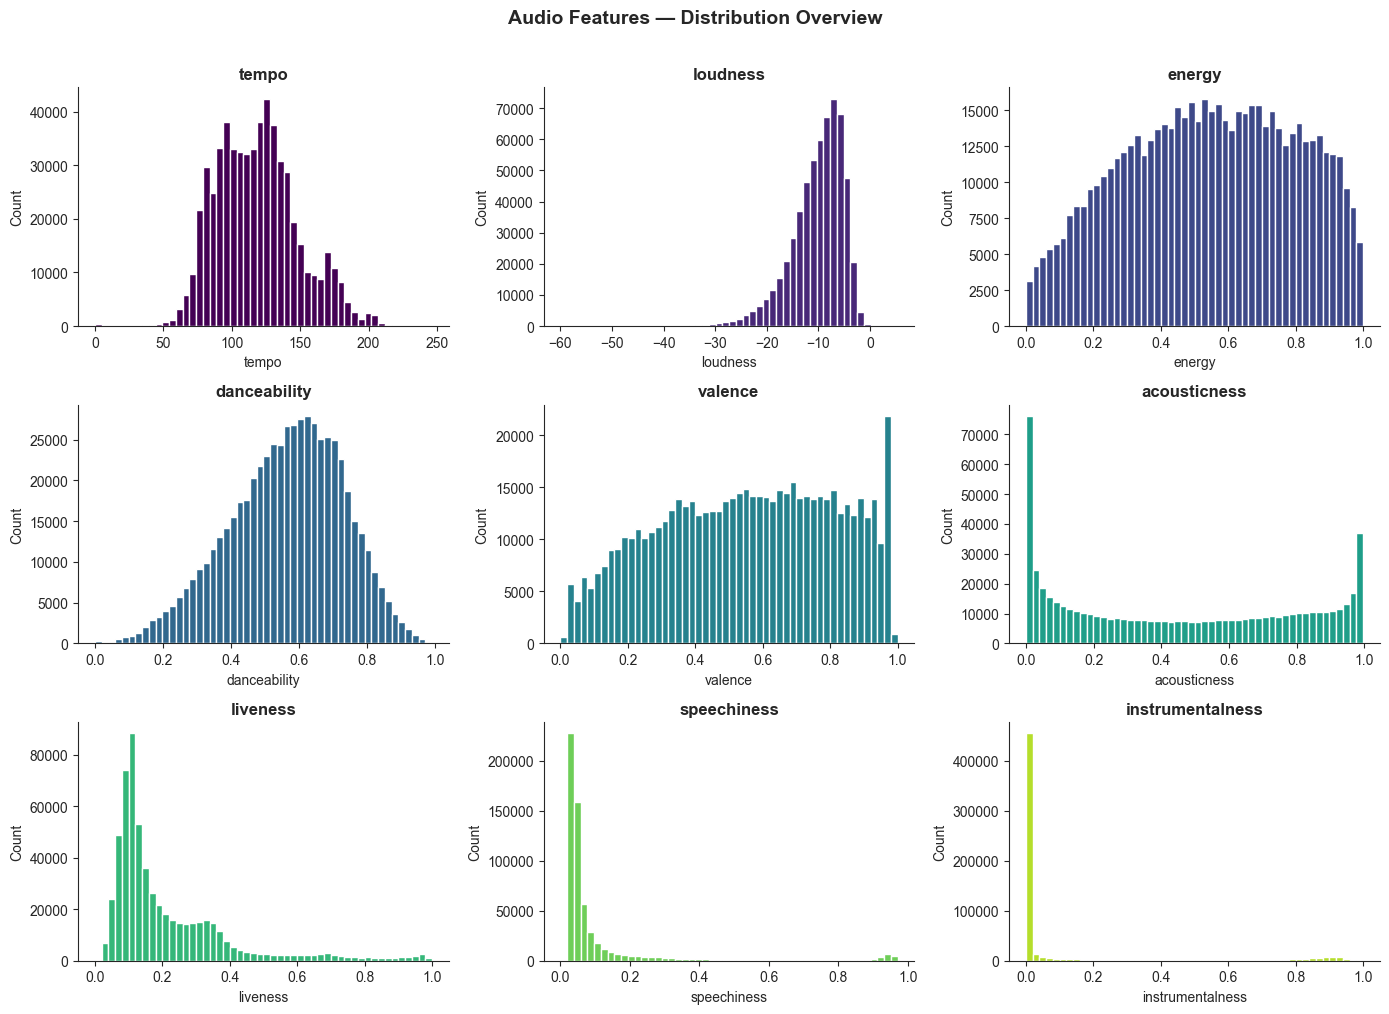

In [4]:
# --- Distribution of all 9 audio features ---
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

# Generate 9 evenly spaced colors from the viridis palette
colors = [plt.cm.viridis(i / len(audio_features)) for i in range(len(audio_features))]

for i, (feature, color) in enumerate(zip(audio_features, colors)):
    axes[i].hist(tracks[feature].dropna(), bins=50,
                 color=color, edgecolor='white')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    sns.despine(ax=axes[i])

plt.suptitle('Audio Features — Distribution Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

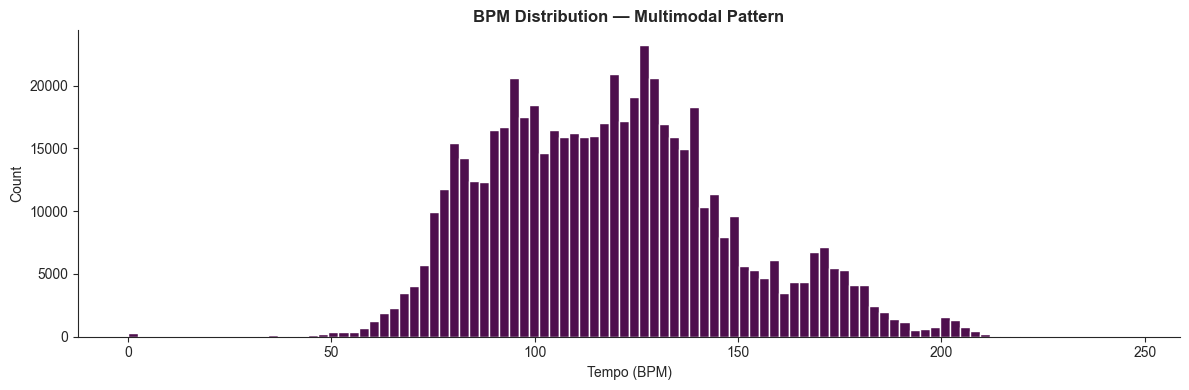

In [5]:
# --- BPM multimodal distribution (core observation) ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(tracks['tempo'], bins=100, color='#4e0f4d', edgecolor='white')
ax.set_title('BPM Distribution — Multimodal Pattern', fontweight='bold')
ax.set_xlabel('Tempo (BPM)')
ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
# --- Outlier highlights ---
print(f"""
⚠️  Outlier Summary
{'─' * 45}
  Tracks with tempo == 0:              {(tracks['tempo'] == 0).sum():,}
  Tracks with loudness < -26dB:        {(tracks['loudness'] < -26).sum():,}
  Tracks with valence == 1.0:          {(tracks['valence'] == 1.0).sum():,}

  instrumentalness — % near 0 (< 0.1): {(tracks['instrumentalness'] < 0.1).mean():.1%}
  instrumentalness — % near 1 (> 0.9): {(tracks['instrumentalness'] > 0.9).mean():.1%}
{'─' * 45}
""")


⚠️  Outlier Summary
─────────────────────────────────────────────
  Tracks with tempo == 0:              328
  Tracks with loudness < -26dB:        6,129
  Tracks with valence == 1.0:          14

  instrumentalness — % near 0 (< 0.1): 82.6%
  instrumentalness — % near 1 (> 0.9): 3.5%
─────────────────────────────────────────────



#### Step 2 — Data Preparation

Based on the EDA findings, the following treatments are applied:

| Feature | Issue | Treatment |
|---|---|---|
| `tempo` | 328 tracks with 0 BPM (detection errors) | Drop rows |
| `loudness` | Long tail below -26 dB (near-silent tracks) | Winsorize at 1st percentile |
| `instrumentalness` | Bimodal: mass at 0, mass at 1, gap in between | Binarize (threshold = 0.5) |
| `speechiness` | Extreme right skew | Square root transform |
| `valence` | 14 tracks with value == 1.0 (encoding artifacts) | Drop rows |

In [7]:
# --- Drop tracks with tempo == 0 (detection errors) ---
tracks = tracks[tracks['tempo'] > 0].copy()

# --- Clip loudness at the 1st percentile ---
p01 = tracks['loudness'].quantile(0.01)
tracks['loudness'] = tracks['loudness'].clip(lower=p01)

# --- Binarize instrumentalness (0 = vocal, 1 = instrumental) ---
tracks['is_instrumental'] = (tracks['instrumentalness'] >= 0.5).astype(int)

# --- Square root transform speechiness to reduce right skew ---
tracks['speechiness_sqrt'] = np.sqrt(tracks['speechiness'])

# --- Drop the 14 tracks with valence == 1.0 (encoding artifacts) ---
tracks = tracks[tracks['valence'] < 1.0].copy()

print(f"""
✅ Data Preparation Complete
{'─' * 35}
  Tracks after preparation: {len(tracks):,}
  New features added:
    - is_instrumental  (binary)
    - speechiness_sqrt (sqrt-transformed)
{'─' * 35}
""")


✅ Data Preparation Complete
───────────────────────────────────
  Tracks after preparation: 586,330
  New features added:
    - is_instrumental  (binary)
    - speechiness_sqrt (sqrt-transformed)
───────────────────────────────────



#### Step 3 — Scaling & Sampling

Two preparation steps before clustering:

- **Filtering:** tracks with `popularity == 0` are removed — they have no
  engagement data and would introduce noise
- **Sampling:** a stratified sample of **50,000 tracks** is drawn proportionally
  by year — necessary because the dataset is temporally imbalanced (modern
  decades have far more tracks than older ones). A pure random sample would
  result in ~80% post-2000 tracks, causing older genres like Jazz and Classical
  to nearly disappear from the clustering.
- **Scaling:** all features are standardized to mean=0, std=1 using
  `StandardScaler` — necessary to prevent high-magnitude features like
  `tempo` or `loudness` from dominating the distance calculations in K-Means

In [8]:
# --- Define final feature set ---
clustering_features = [
    'tempo', 'loudness', 'energy', 'danceability',
    'valence', 'acousticness', 'liveness',
    'speechiness_sqrt', 'is_instrumental'
]

# --- Filter: remove tracks with no popularity data ---
tracks_model = tracks[tracks['popularity'] > 0].copy()

# --- Add original tempo to tracks_model BEFORE sampling ---
# At this point tracks_model still has pre-scaled tempo values
# We rename it to keep it separate from the scaled version

tracks_model['tempo_bpm'] = tracks_model['tempo'].copy()

In [9]:
# --- Stratified sample by year ---
SAMPLE_SIZE = 50_000

tracks_sample = (
    tracks_model
    # 1. Split the dataframe into groups, one per year
    .groupby('year', group_keys=False)

    # 2. Within each year, sample proportionally
    #    frac = 50k / total tracks ≈ 9.2% of each year
    .apply(lambda x: x.sample(
        frac=SAMPLE_SIZE / len(tracks_model),
        random_state=42
    ))
    .reset_index(drop=True)   # 3. Flatten the grouped index back to integers

    # 4. Cap at exactly 50,000 (rounding across years may give ±few rows)
    .sample(n=SAMPLE_SIZE, random_state=42)
    .reset_index(drop=True)   # 5. Clean index again after final sample
)

# --- Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tracks_sample[clustering_features])

print(f"""
✅ Scaling & Sampling Complete
{'─' * 35}
  Tracks after popularity filter: {len(tracks_model):,}
  Sample size:                    {len(tracks_sample):,}
  Feature matrix shape:           {X_scaled.shape}
{'─' * 35}
""")


✅ Scaling & Sampling Complete
───────────────────────────────────
  Tracks after popularity filter: 541,707
  Sample size:                    50,000
  Feature matrix shape:           (50000, 9)
───────────────────────────────────



#### Step 4 — Choosing the Optimal Number of Clusters

Two complementary metrics are used to select the optimal k:

- **Elbow Method:** plots inertia (WCSS) as k increases — look for the point
  where the curve stops dropping sharply ("elbow")
- **Silhouette Score:** measures how similar each track is to its own cluster
  vs neighbouring clusters — higher is better (range: -1 to 1)

> In music data, the elbow is often soft (no sharp bend). In that case,
> the **Silhouette Score becomes the tiebreaker**.

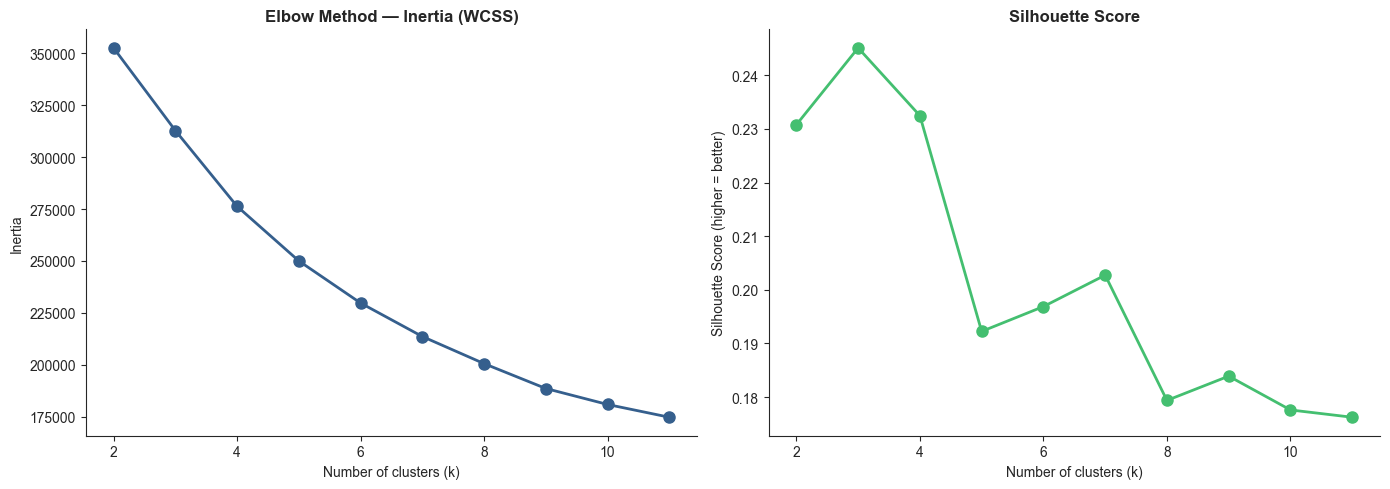

In [10]:
k_range = range(2, 12)
inertia_values = []
silhouette_values = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',  # spreads initial centroids apart → better convergence
        n_init=10,         # runs 10 times, keeps best result → guards against bad luck
        max_iter=300,      # max iterations per run (sklearn default)
        random_state=42    # fixed seed → reproducible results
    )
    labels = kmeans.fit_predict(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(
        silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42)
    )

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, 'o-', linewidth=2, markersize=8,
             color=plt.cm.viridis(0.3))
axes[0].set_title('Elbow Method — Inertia (WCSS)', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
sns.despine(ax=axes[0])

axes[1].plot(k_range, silhouette_values, 'o-', linewidth=2, markersize=8,
             color=plt.cm.viridis(0.7))
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [11]:
# --- Summary table ---
print(f"\n{'k':>4} {'Inertia':>12} {'Silhouette':>12}")
print('─' * 30)
for k, inertia, sil in zip(k_range, inertia_values, silhouette_values):
    print(f"{k:>4} {inertia:>12.1f} {sil:>12.4f}")


   k      Inertia   Silhouette
──────────────────────────────
   2     352691.0       0.2308
   3     312883.8       0.2451
   4     276347.0       0.2325
   5     250022.6       0.1923
   6     229741.5       0.1969
   7     213597.4       0.2027
   8     200530.0       0.1794
   9     188547.0       0.1839
  10     180846.7       0.1776
  11     174692.7       0.1762


#### Step 5 — K-Means Clustering

Based on the Elbow and Silhouette analysis, **k=6 and k=7** are selected as
the best candidates — both align with the 6 main Spotify genres (Pop, Rock,
Hip-Hop/Rap, EDM, Latin, R&B) and show a secondary silhouette recovery at k=7.

> **Why not k=3?** Although k=3 produced the highest Silhouette Score (0.245),
> it is too coarse for meaningful genre analysis — it collapses all music into
> three broad archetypes (acoustic, energetic, speech-driven), merging genres
> like Pop, R&B and Latin into a single undifferentiated cluster.

> **Note on GMM:** A Gaussian Mixture Model was evaluated as an alternative,
> since genres are known to overlap in audio feature space. However, GMM
> produced silhouette scores of ~0.04 for both k=6 and k=7 — clusters were
> geometrically indistinguishable and practically uninterpretable. K-Means
> was retained for its superior separation and interpretability.

Both k=6 and k=7 are fitted. Each cluster is then profiled on its mean audio
features before being assigned an interpretive label.

In [12]:
profile_features = [
    'tempo', 'loudness', 'energy', 'danceability',
    'valence', 'acousticness', 'liveness',
    'speechiness', 'instrumentalness'
]

profiles = {}

for k in [6, 7]:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',  # spreads initial centroids apart → better convergence
        n_init=10,         # runs 10 times, keeps best result → guards against bad luck
        max_iter=300,      # max iterations per run (sklearn default)
        random_state=42    # fixed seed → reproducible results
    )
    tracks_sample[f'cluster_k{k}'] = kmeans.fit_predict(X_scaled)
    
    # --- Compute mean audio features per cluster ---
    profiles[k] = (
        tracks_sample
        .groupby(f'cluster_k{k}')[profile_features]
        .mean()
        .round(3)
    )

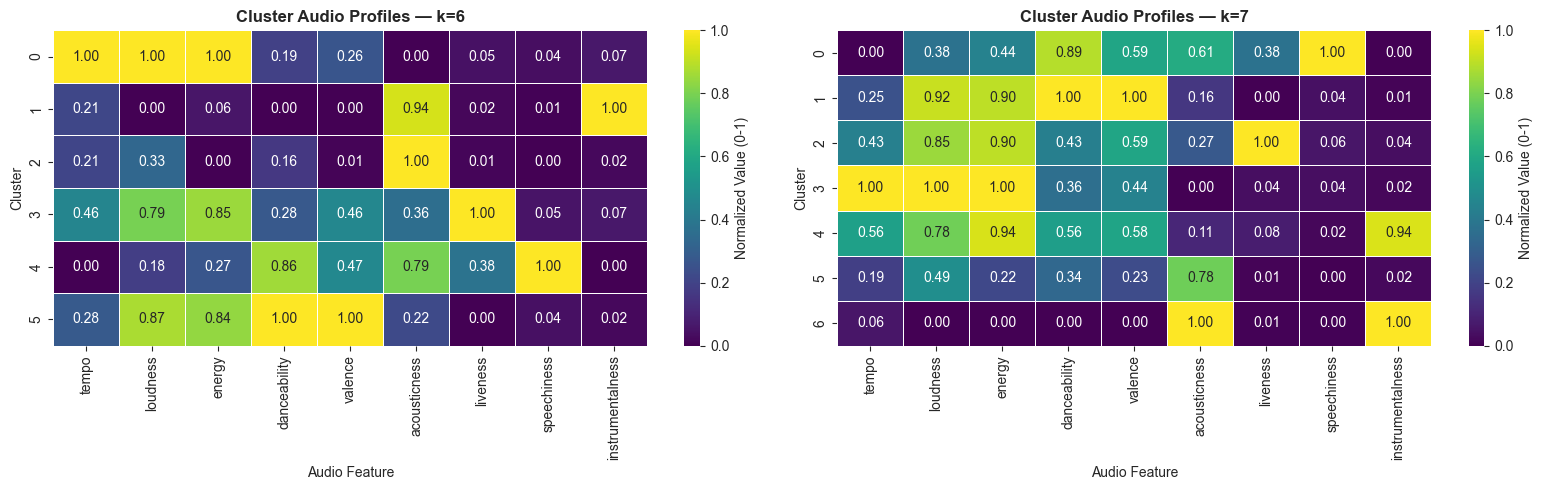

In [13]:
scaler_viz = MinMaxScaler()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, k in zip(axes, [6, 7]):
    # Normalize profiles to 0-1 so all features are visually comparable
    profile_normalized = pd.DataFrame(
        scaler_viz.fit_transform(profiles[k]),
        columns=profile_features,
        index=profiles[k].index
    )
    sns.heatmap(
        profile_normalized,
        annot=True, fmt='.2f',
        cmap='viridis',
        linewidths=0.5,
        ax=ax,
        cbar_kws={'label': 'Normalized Value (0-1)'}
    )
    ax.set_title(f'Cluster Audio Profiles — k={k}', fontweight='bold')
    ax.set_xlabel('Audio Feature')
    ax.set_ylabel('Cluster')

plt.tight_layout()
plt.show()

In [14]:
# --- Names derived from audio feature profiles above ---
# Keywords: High (>0.75) | Mid-High (0.50-0.75) | Mid-Low (0.25-0.50) | Low (<0.25)

cluster_names_k6 = {
    0: 'High-Energy / Fast',     # tempo=High, energy=High, loudness=High
    1: 'Acoustic Instrumental',  # acousticness=High, instrumentalness=High
    2: 'Acoustic Vocal',         # acousticness=High, energy=Low, instrumentalness=Low
    3: 'Live Recordings',        # liveness=High, energy=Mid-High
    4: 'Speech-Driven',          # speechiness=High, danceability=Mid-High
    5: 'Dance / Upbeat'          # danceability=High, valence=High, loudness=Mid-High
}

cluster_names_k7 = {
    0: 'Speech-Driven',          # speechiness=High, danceability=Mid-High
    1: 'Dance / Upbeat',         # danceability=High, valence=High, loudness=Mid-High
    2: 'Live Recordings',        # liveness=High, energy=Mid-High
    3: 'High-Energy / Fast',     # tempo=High, energy=High, loudness=High
    4: 'Energetic Instrumental', # instrumentalness=High, energy=High
    5: 'Acoustic Vocal',         # acousticness=Mid-High, energy=Low
    6: 'Acoustic Instrumental'   # acousticness=High, instrumentalness=High
}

for k, names in [(6, cluster_names_k6), (7, cluster_names_k7)]:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',  # spreads initial centroids apart → better convergence
        n_init=10,         # runs 10 times, keeps best result → guards against bad luck
        max_iter=300,      # max iterations per run (sklearn default)
        random_state=42    # fixed seed → reproducible results
    )
    tracks_sample[f'cluster_k{k}'] = kmeans.fit_predict(X_scaled)
    tracks_sample[f'cluster_k{k}_label'] = tracks_sample[f'cluster_k{k}'].map(names)

print(f"""
✅ K-Means Fitting Complete
{'─' * 35}
  k=6 cluster distribution:
{tracks_sample['cluster_k6_label'].value_counts().to_string()}

  k=7 cluster distribution:
{tracks_sample['cluster_k7_label'].value_counts().to_string()}
{'─' * 35}
""")


✅ K-Means Fitting Complete
───────────────────────────────────
  k=6 cluster distribution:
cluster_k6_label
Dance / Upbeat           16698
Acoustic Vocal           12967
High-Energy / Fast       10849
Acoustic Instrumental     3862
Live Recordings           3265
Speech-Driven             2359

  k=7 cluster distribution:
cluster_k7_label
Dance / Upbeat            16473
Acoustic Vocal            12749
High-Energy / Fast        10533
Live Recordings            3175
Acoustic Instrumental      2429
Speech-Driven              2352
Energetic Instrumental     2289
───────────────────────────────────



#### Step 6 — Visualization

**BPM Distribution by Cluster**

To verify whether the clustering successfully decomposes the original
multimodal BPM distribution, we plot the **tempo density** for each cluster
using a ridge plot (KDE curves stacked by cluster).

Each row shows the BPM distribution of one cluster, with a **dashed line
at the median**. Well-separated peaks across clusters confirm that the
algorithm captured groups with genuinely different rhythmic characteristics.

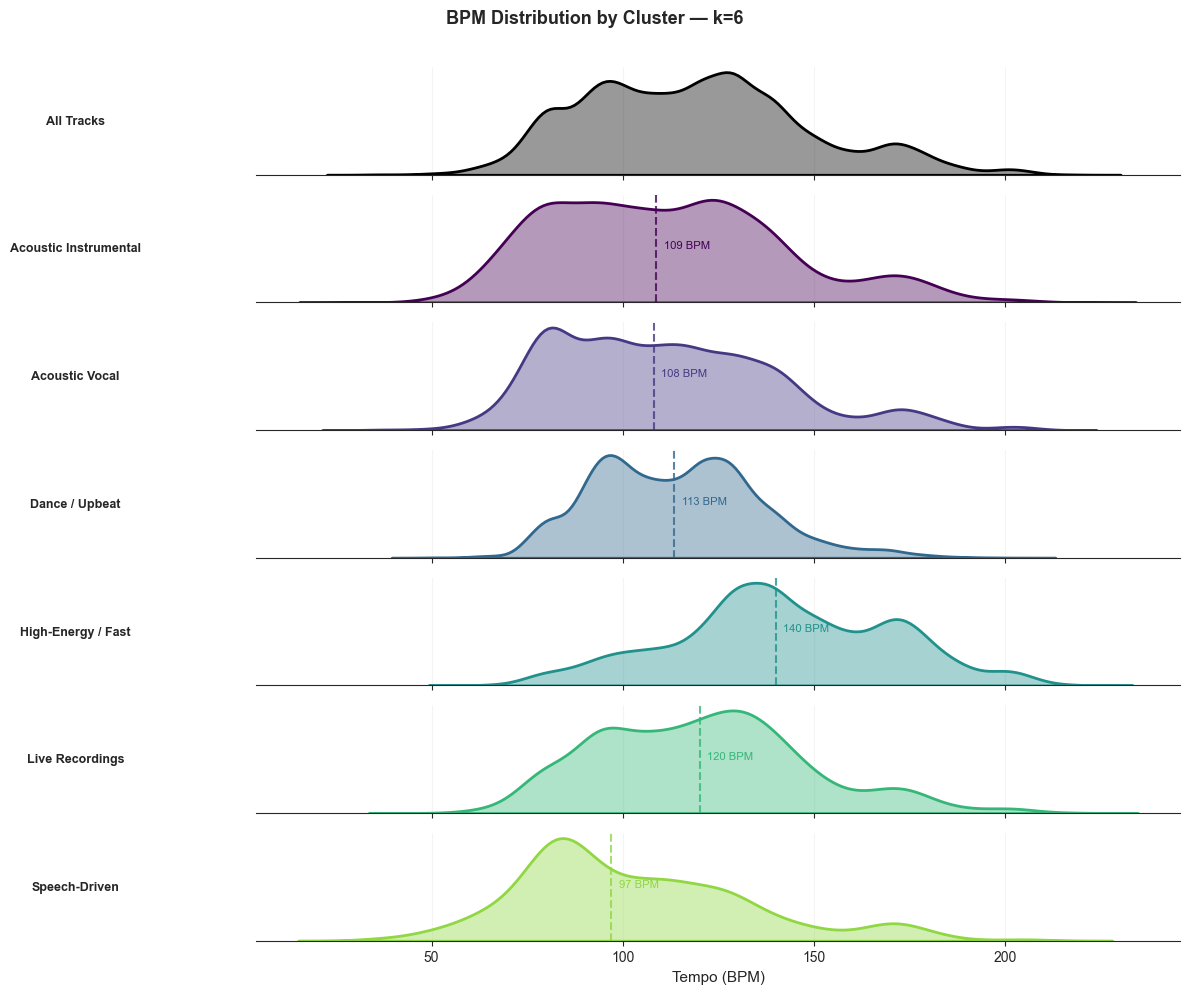

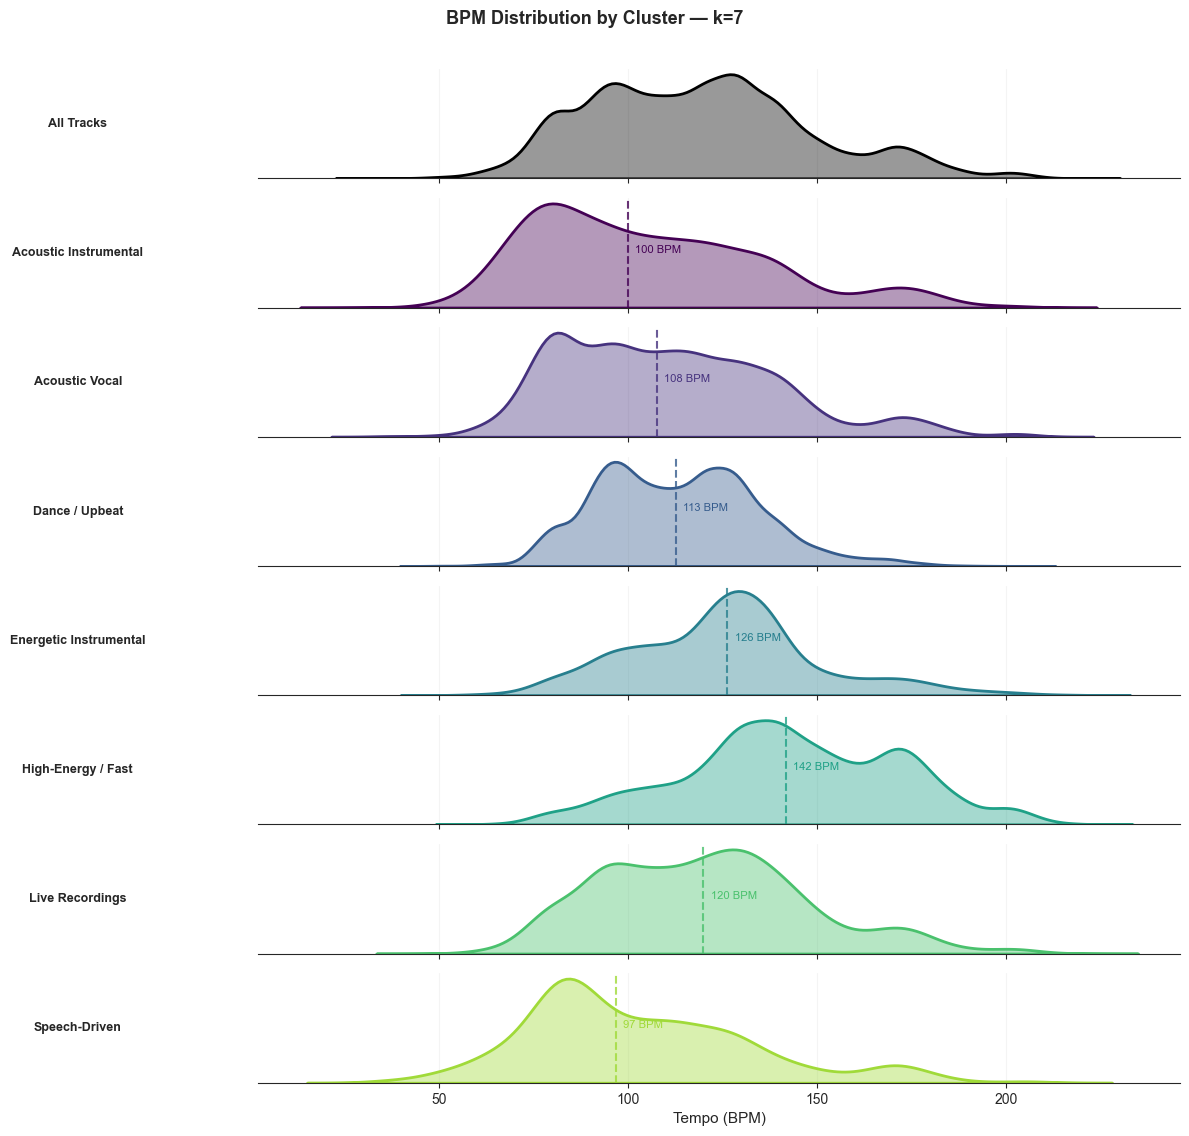

In [15]:
for k in [6, 7]:
    label_col = f'cluster_k{k}_label'
    cluster_names = sorted(tracks_sample[label_col].dropna().unique())
    colors = [plt.cm.viridis(i / len(cluster_names))
              for i in range(len(cluster_names))]

    # +1 row for the unclustered reference plot on top
    n_rows = len(cluster_names) + 1
    fig, axes = plt.subplots(n_rows, 1,
                             figsize=(12, n_rows * 1.4),  # 1.4 = 1.8 * 0.8 (~20% less)
                             sharex=True)

    # --- Row 0: unclustered reference ---
    sns.kdeplot(tracks_sample['tempo'].dropna(), ax=axes[0],
                fill=True, color='k', alpha=0.4, linewidth=2)
    axes[0].set_ylabel('All Tracks', rotation=0, labelpad=130,
                       fontsize=9, fontweight='bold', va='center')
    axes[0].set_yticks([])
    sns.despine(ax=axes[0], left=True)
    axes[0].grid(axis='x', alpha=0.2)

    # --- Remaining rows: one per cluster ---
    for ax, cluster_name, color in zip(axes[1:], cluster_names, colors):
        subset = tracks_sample[
            tracks_sample[label_col] == cluster_name
        ]['tempo'].dropna()

        sns.kdeplot(subset, ax=ax, fill=True,
                    color=color, alpha=0.4, linewidth=2)

        median_bpm = subset.median()
        ax.axvline(median_bpm, color=color, linewidth=1.5,
                   linestyle='--', alpha=0.8)
        ax.text(median_bpm + 2, ax.get_ylim()[1] * 0.5,
                f'{median_bpm:.0f} BPM', fontsize=8, color=color)

        ax.set_ylabel(cluster_name, rotation=0, labelpad=130,
                      fontsize=9, fontweight='bold', va='center')
        ax.set_yticks([])
        sns.despine(ax=ax, left=True)
        ax.grid(axis='x', alpha=0.2)

    axes[-1].set_xlabel('Tempo (BPM)', fontsize=11)
    fig.suptitle(f'BPM Distribution by Cluster — k={k}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

#### 📊 BPM Distribution by Cluster — Interpretation

**Overall Pattern**
> The "All Tracks" reference row confirms the original observation: the full
> dataset has a **multimodal BPM distribution** with peaks around 80-100 BPM,
> 120-130 BPM and a smaller tail above 160 BPM. The clustering successfully
> decomposes this pattern into groups with distinct rhythmic profiles.


**What Both k=6 and k=7 Agree On**
>Two clusters show the clearest BPM separation and are stable across both solutions:
> - **Speech-Driven** (median 97 BPM) → consistently the lowest-tempo cluster,
>  with a sharp peak around 80-90 BPM. Reflects Hip-Hop/Rap's characteristic
>  half-time feel.
> - **High-Energy / Fast** (median 140-142 BPM) → consistently the highest-tempo
>  cluster, shifted far right relative to all others. Captures Rock and EDM.
> The remaining clusters (Acoustic Instrumental, Acoustic Vocal, Dance/Upbeat,

>Live Recordings) all share similar median BPMs in the **108-120 BPM range**,
>confirming that tempo alone is not sufficient to distinguish them — their
>separation is driven by other features (acousticness, danceability, liveness).


**What Changes Going from k=6 to k=7**

> The key difference is the addition of **Energetic Instrumental** (median 126 BPM),
> which does not exist in k=6. This new cluster sits between Dance/Upbeat (113 BPM)
> and High-Energy/Fast (142 BPM) — a BPM range that in k=6 was absorbed into the
> High-Energy/Fast cluster.

> Concretely, k=7 splits what k=6 called "High-Energy/Fast" into two subgroups:

| Cluster | Median BPM | Distinguishing feature |
|---|---|---|
| Energetic Instrumental | 126 BPM | High instrumentalness — likely EDM |
| High-Energy / Fast | 142 BPM | High energy + loudness — likely Rock |

This is the **main added value of k=7**: it separates electronic instrumental
music (EDM) from guitar-driven high-energy music (Rock), two genres that share
high energy but differ in instrumentalness and tempo range.

#### Limitations — Why Neither Solution Fully Recovers Genre Boundaries

Despite the partial separation visible in the ridge plots, both k=6 and k=7
**fail to cleanly reconstruct human-defined genre taxonomies**. This is not
a failure of the algorithm — it reflects a fundamental property of the data.

Musical genres are cultural categories defined by history, aesthetics and
social context, not purely by acoustic signal. As a result, many genres
occupy **overlapping regions of the audio feature space**:

- **Pop, R&B and Latin** share similar danceability, valence and energy
  profiles — the algorithm consistently merges them into a single cluster
- **Rock** spans an exceptionally wide acoustic range, from quiet
  acoustic folk to loud distorted metal, making it impossible to
  capture with a single centroid
- **Jazz and Country** both tend toward moderate tempo and high
  acousticness, causing them to cluster together despite being
  culturally distinct genres

> The clusters should therefore be interpreted not as genre labels, but as
> **acoustic archetypes** — broader perceptual groupings (e.g. "acoustic",
> "energetic", "speech-driven") that cut across traditional genre lines.
> Audio features alone capture *how a song sounds*, but not *what genre it
> belongs to*.

### ❕Clustering Analysis — Conclusions

#### Methodology
Unsupervised **K-Means clustering** was applied to a stratified sample of
**50,000 tracks** using 9 Spotify audio features: `tempo`, `loudness`,
`energy`, `danceability`, `valence`, `acousticness`, `liveness`,
`speechiness` (sqrt-transformed), and `is_instrumental` (binarized).

The optimal number of clusters was selected combining the **Elbow Method**
and **Silhouette Score** (k=2 to k=11). **GMM** was also evaluated but
discarded due to near-zero silhouette scores (~0.04), producing clusters
that were geometrically indistinguishable and uninterpretable.

#### Key Findings

✅ **What the clustering captured well**

| Cluster | Median BPM | Defining Features | Inferred Genre Affinity |
|---|---|---|---|
| 🗣️ Speech-Driven | 97 BPM | High speechiness, high danceability | Hip-Hop / Rap |
| ⚡ High-Energy / Fast | 140 BPM | High energy, loudness, fast tempo | Rock, EDM |
| 🎻 Acoustic Instrumental | 109 BPM | High acousticness, high instrumentalness | Classical |
| 💃 Dance / Upbeat | 113 BPM | High danceability, high valence | Latin, Pop, R&B |
| 🎤 Live Recordings | 120 BPM | Very high liveness | All genres |
| 🎸 Acoustic Vocal | 108 BPM | High acousticness, low instrumentalness | Country, Jazz |


⚠️ **What the clustering could not separate**
- **Pop, R&B and Latin** consistently co-clustered due to nearly identical
  audio profiles
- **Rock** split across multiple clusters, reflecting its wide internal
  acoustic range
- **Classical** was the only genre to achieve near-isolation in feature space

---

#### Model Comparison

| Model | Silhouette Score | Notes |
|---|---|---|
| K-Means k=3 | 0.245 | Best geometric separation, too coarse |
| K-Means k=6 | 0.197 | Best balance of interpretability and separation |
| K-Means k=7 | 0.203 | Adds "Energetic Instrumental" — separates EDM from Rock |



#### Overall Conclusion

> *Spotify's audio features alone are **insufficient to reconstruct
> human-defined genre taxonomies**. The clusters instead reflect broader
> **acoustic archetypes** — acoustic vs electronic, speech-driven vs
> instrumental, studio vs live — that cut across traditional genre lines.*
>
> *Genre is a **social and cultural construct** that audio signal analysis
> alone cannot fully capture. The most reliably separable genres —
> **Hip-Hop/Rap** (speechiness) and **Classical** (acousticness +
> instrumentalness) — are precisely those with the most distinctive and
> non-overlapping audio signatures.*

In [ ]:
scaler_export = MinMaxScaler()

# --- Fit scaler ONCE on tracks_sample feature columns ---
# All exports will use this same scale as reference
tracks_sample_export = tracks_sample.copy()
tracks_sample_export[profile_features] = scaler_export.fit_transform(
    tracks_sample[profile_features]
)

# --- Clean version WITHOUT cluster labels (unclustered reference) ---
cluster_cols = [c for c in tracks_sample_export.columns if 'cluster' in c]
tracks_sample_clean = tracks_sample_export.drop(columns=cluster_cols)

# --- Cluster profiles: apply the SAME fitted scaler (transform only, no refit) ---
for k, names in [(6, cluster_names_k6), (7, cluster_names_k7)]:
    profile = profiles[k].copy()
    
    # Use transform (not fit_transform) → same scale as tracks_sample
    profile[profile_features] = scaler_export.transform(profile[profile_features])
    profile['cluster_label'] = profile.index.map(names)
    profile['k'] = k
    profile.index.name = 'cluster_id'
    
    if k == 6:
        cluster_profiles_k6 = profile
    else:
        cluster_profiles_k7 = profile

# --- Export ---
os.makedirs('../data/exports', exist_ok=True) #create exports folder if it doesn't exist
tracks_sample_clean.to_csv('../data/exports/tracks_sample.csv', index=False)
tracks_sample_export.to_csv('../data/exports/tracks_sample_clustered.csv', index=False)
cluster_profiles_k6.to_csv('../data/exports/cluster_profiles_k6.csv', index=False)
cluster_profiles_k7.to_csv('../data/exports/cluster_profiles_k7.csv', index=False)